In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import pandas as pd

news_df = pd.read_csv(
    "/content/drive/MyDrive/truthlens_ai/processed/clean_news_dataset.csv"
)

news_df.head()

,content,label,clean_content
0,Donald Trump Sends Out Embarrassing New Year’...,0,donald trump sends out embarrassing new year s...
1,Drunk Bragging Trump Staffer Started Russian ...,0,drunk bragging trump staffer started russian c...
2,Sheriff David Clarke Becomes An Internet Joke...,0,sheriff david clarke becomes an internet joke ...
3,Trump Is So Obsessed He Even Has Obama’s Name...,0,trump is so obsessed he even has obama s name ...
4,Pope Francis Just Called Out Donald Trump Dur...,0,pope francis just called out donald trump duri...


In [8]:
print(X_train.shape)
print(X_test.shape)

(35751,)
(8938,)


In [11]:
news_df["clean_content"].isna().sum()

np.int64(9)

In [12]:
news_df = news_df.dropna(subset=["clean_content"])

In [13]:
print(news_df["clean_content"].isna().sum())

0


In [14]:
news_df["clean_content"] = news_df["clean_content"].astype(str)

In [15]:
X = news_df["clean_content"]
y = news_df["label"]

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2)
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [18]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [19]:
y_pred = model.predict(X_test_tfidf)

In [20]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.9907117278424351

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4694
           1       0.99      0.99      0.99      4242

    accuracy                           0.99      8936
   macro avg       0.99      0.99      0.99      8936
weighted avg       0.99      0.99      0.99      8936



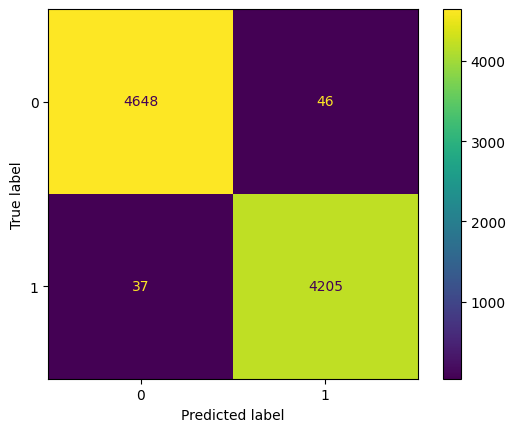

In [21]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

plt.show()

In [22]:
import joblib

joblib.dump(model,
            "/content/drive/MyDrive/truthlens_ai/models/logistic_regression_model.pkl")

joblib.dump(tfidf,
            "/content/drive/MyDrive/truthlens_ai//models/tfidf_vectorizer.pkl")

['/content/drive/MyDrive/truthlens_ai//models/tfidf_vectorizer.pkl']

In [26]:
print(clean_text("Hello World"))

None


In [27]:
import re

def clean_text(text):
    text = str(text)

    # Lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)

    # Remove Twitter handles
    text = re.sub(r'@\w+', '', text)

    # Remove punctuation and special characters
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [28]:
sample_news = """
Scientists discover a new method to improve battery life in electric vehicles.
"""

cleaned = clean_text(sample_news)

vector = tfidf.transform([cleaned])

prediction = model.predict(vector)

print(prediction)


[1]


In [29]:
model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [30]:
y_pred = model.predict(X_test_tfidf)

In [31]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9907117278424351


In [32]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4694
           1       0.99      0.99      0.99      4242

    accuracy                           0.99      8936
   macro avg       0.99      0.99      0.99      8936
weighted avg       0.99      0.99      0.99      8936



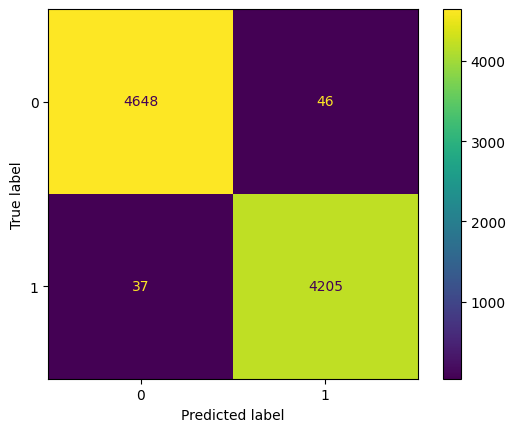

In [33]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.show()

In [34]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

nb_pred = nb_model.predict(X_test_tfidf)

from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, nb_pred))

Accuracy: 0.9524395702775291


In [35]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train_tfidf, y_train)

rf_pred = rf_model.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, rf_pred))

Accuracy: 0.9984333034914951


In [36]:
import joblib

joblib.dump(
    model,
    "/content/drive/MyDrive/truthlens_ai/models/fake_news_model.pkl"
)

joblib.dump(
    tfidf,
    "/content/drive/MyDrive/truthlens_ai/models/tfidf_vectorizer.pkl"
)

print("Model Saved Successfully")

['/content/drive/MyDrive/truthlens_ai/models/tfidf_vectorizer.pkl']

In [37]:
import os

print(os.listdir("/content/drive/MyDrive/truthlens_ai/models"))

['logistic_regression_model.pkl', 'tfidf_vectorizer.pkl', 'fake_news_model.pkl']


In [38]:
import joblib

loaded_model = joblib.load(
    "/content/drive/MyDrive/truthlens_ai/models/fake_news_model.pkl"
)

loaded_vectorizer = joblib.load(
    "/content/drive/MyDrive/truthlens_ai/models/tfidf_vectorizer.pkl"
)

print("Loaded Successfully")

Loaded Successfully


In [39]:
import re

def clean_text(text):
    text = str(text)
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


def predict_news(news_text):

    cleaned = clean_text(news_text)

    vector = loaded_vectorizer.transform([cleaned])

    prediction = loaded_model.predict(vector)[0]

    probability = loaded_model.predict_proba(vector)[0]

    return {
        "prediction": "Real" if prediction == 1 else "Fake",
        "confidence": float(max(probability))
    }

In [40]:
sample = """
Scientists discover a new battery technology that increases EV range by 40 percent.
"""

print(predict_news(sample))

{'prediction': 'Fake', 'confidence': 0.6056579649995584}


In [41]:
sample = """
President Biden met with world leaders to discuss economic cooperation and climate policy.
"""

print(predict_news(sample))

{'prediction': 'Fake', 'confidence': 0.6653343259307714}


In [42]:
sample = """
A secret government agency confirmed that aliens are controlling global elections.
"""

print(predict_news(sample))

{'prediction': 'Fake', 'confidence': 0.849968355543284}


In [43]:
print(news_df["label"].value_counts())

label
0    23469
1    21211
Name: count, dtype: int64


In [45]:
print(news_df.iloc[100]["clean_content"][:1000])
print(news_df.iloc[100]["label"])

watch joe biden just wrecked trump in six words and it s hilarious former vice president joe biden was asked on monday by matt lauer on nbc s today to name something specific that donald trump has been doing well well that seems like a trick question since trump has passed no major legislation and reaches across the aisle only to take shots at democrats in his twitter timeline during his morning rage tweets so biden struggled to find something anything that trump has done well since taking office i think there s a number of things he s doing well but even the things he s doing well it s how he does them biden said it s more the tone of this administration that bothers me he continued with all due respect you haven t come up with one thing you think he s doing well lauer said well i think he married very well biden joked although biden didn t mention which of trump s three marriages he s speaking of trump s first marriage to ivana ended after he had an affair with marla maples trump wen

In [46]:
sample = news_df.iloc[100]["clean_content"]

print(predict_news(sample))

{'prediction': 'Fake', 'confidence': 0.9753147832918972}


In [56]:
import joblib

model1 = joblib.load("/content/drive/MyDrive/truthlens_ai/models/fake_news_model.pkl")
model2 = joblib.load("/content/drive/MyDrive/truthlens_ai/models/logistic_regression_model.pkl")

print(type(model1))
print(type(model2))
print(model1.get_params())
print(model2.get_params())

<class 'sklearn.linear_model._logistic.LogisticRegression'>
<class 'sklearn.linear_model._logistic.LogisticRegression'>
{'C': 1.0, 'class_weight': None, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': None, 'max_iter': 1000, 'multi_class': 'deprecated', 'n_jobs': None, 'penalty': 'l2', 'random_state': 42, 'solver': 'lbfgs', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}
{'C': 1.0, 'class_weight': None, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': None, 'max_iter': 1000, 'multi_class': 'deprecated', 'n_jobs': None, 'penalty': 'l2', 'random_state': 42, 'solver': 'lbfgs', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}
